# Avaliação Comparativa — M2 Crop U-Ignore vs M3 Crop U-Ones
**Projeto Integrador SENAI FATESG 2025/2026**  
Variável isolada: política de labels incertos | Mesmo preprocessing (Center Crop) | Mesmo valid set

## SEÇÃO 0 — Setup

In [1]:
!pip install -q tensorflow keras scikit-learn matplotlib pandas numpy scipy

In [2]:
import os, json, random, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image as PILImage
from scipy import stats
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    roc_auc_score, average_precision_score,
    roc_curve, precision_recall_curve,
    f1_score, confusion_matrix, brier_score_loss
)

import tensorflow as tf
from tensorflow.keras import layers

from google.colab import drive
drive.mount('/content/drive')

SEED = 42
random.seed(SEED); np.random.seed(SEED); tf.random.set_seed(SEED)
print(f'TF {tf.__version__} | GPU: {tf.config.list_physical_devices("GPU")}')

Mounted at /content/drive
TF 2.20.0 | GPU: []


In [3]:
# ── Caminhos ──────────────────────────────────────────────────────────────────
BASE    = '/content/drive/MyDrive'
M2_DIR  = f'{BASE}/datasets_pi_2026/modelos/M2_NIH_CheXpert_Crop_UIgnore'
M3_DIR  = f'{BASE}/datasets_pi_2026/modelos/M3_CheXpert_Crop_UOnes'

M2_MODEL = f'{M2_DIR}/m2_crop_final.keras'
M3_MODEL = f'{M3_DIR}/m3_final.keras'

# Mesmo valid set — Center Crop para ambos
CHEX_DIR  = f'{BASE}/datasets_pi_2026/estruturacao/Stanford_Cropping'
VALID_CSV = f'{CHEX_DIR}/chex_crop_valid.csv'

OUT_DIR = f'{BASE}/datasets_pi_2026/avaliacao_comparativa_m2_m3'
os.makedirs(OUT_DIR, exist_ok=True)

LABELS   = ['atelectasis','cardiomegaly','pleural_effusion',
            'pneumothorax','consolidation','edema']
N_LABELS = len(LABELS)
IMG_SIZE = 512

print('Verificando arquivos:')
for path, name in [(M2_MODEL,'M2 model'),(M3_MODEL,'M3 model'),(VALID_CSV,'Valid CSV')]:
    size = f'{os.path.getsize(path)/1024**2:.1f} MB' if os.path.exists(path) else '—'
    print(f'  {"✅" if os.path.exists(path) else "❌"} {name:<12}: {size}')

Verificando arquivos:
  ✅ M2 model    : 252.0 MB
  ✅ M3 model    : 252.0 MB
  ✅ Valid CSV   : 0.0 MB


## SEÇÃO 1 — Classes Customizadas e Carregamento dos Modelos

In [5]:
# ── M2: FocalLossUIgnore + MaskedBinaryAccuracy ───────────────────────────────
class FocalLossUIgnore(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma = gamma; self.alpha = alpha
        self.label_weights = (tf.constant(label_weights, dtype=tf.float32)
                              if label_weights is not None else tf.ones(N_LABELS))
    def call(self, y_true, y_pred):
        labels = y_true[:, :N_LABELS]; mask = y_true[:, N_LABELS:]
        y_pred = tf.clip_by_value(y_pred, 1e-7, 1-1e-7)
        bce    = -(labels*tf.math.log(y_pred)+(1-labels)*tf.math.log(1-y_pred))
        p_t    = labels*y_pred+(1-labels)*(1-y_pred)
        alpha_t= labels*self.alpha+(1-labels)*(1-self.alpha)
        focal  = alpha_t*tf.pow(1-p_t,self.gamma)*bce*self.label_weights
        return tf.reduce_sum(focal*mask)/(tf.reduce_sum(mask)+1e-7)
    def get_config(self):
        c = super().get_config()
        c.update({'gamma':self.gamma,'alpha':self.alpha,
                  'label_weights':self.label_weights.numpy().tolist()})
        return c

class MaskedBinaryAccuracy(tf.keras.metrics.Metric):
    def __init__(self, n_labels=N_LABELS, name='accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels = n_labels
        self.acc = tf.keras.metrics.BinaryAccuracy()
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.acc.update_state(y_true[:,:self.n_labels], y_pred)
    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()
    def get_config(self):
        c = super().get_config(); c['n_labels']=self.n_labels; return c

# ── M3: FocalLossLabelSmoothing + BinaryAccuracyM3 ───────────────────────────
class FocalLossLabelSmoothing(tf.keras.losses.Loss):
    def __init__(self, gamma=2.0, alpha=0.25, epsilon=0.05,
                 label_weights=None, **kwargs):
        super().__init__(**kwargs)
        self.gamma=gamma; self.alpha=alpha; self.epsilon=epsilon
        self.label_weights=(tf.constant(label_weights,dtype=tf.float32)
                            if label_weights is not None else tf.ones(N_LABELS))
    def call(self, y_true, y_pred):
        y_smooth = y_true*(1-self.epsilon)+(1-y_true)*self.epsilon
        y_pred   = tf.clip_by_value(y_pred,1e-7,1-1e-7)
        bce      = -(y_smooth*tf.math.log(y_pred)+(1-y_smooth)*tf.math.log(1-y_pred))
        p_t      = y_true*y_pred+(1-y_true)*(1-y_pred)
        alpha_t  = y_true*self.alpha+(1-y_true)*(1-self.alpha)
        focal    = alpha_t*tf.pow(1-p_t,self.gamma)*bce
        return tf.reduce_mean(focal*self.label_weights)
    def get_config(self):
        c = super().get_config()
        c.update({'gamma':self.gamma,'alpha':self.alpha,'epsilon':self.epsilon,
                  'label_weights':self.label_weights.numpy().tolist()})
        return c

class BinaryAccuracyM3(tf.keras.metrics.Metric):
    def __init__(self, name='accuracy', **kwargs):
        super().__init__(name=name, **kwargs)
        self.acc = tf.keras.metrics.BinaryAccuracy()
    def update_state(self, y_true, y_pred, sample_weight=None):
        self.acc.update_state(y_true, y_pred)
    def result(self): return self.acc.result()
    def reset_state(self): self.acc.reset_state()

class MacroAUROC(tf.keras.metrics.Metric):
    def __init__(self, n_labels=N_LABELS, name='macro_auroc', **kwargs):
        super().__init__(name=name, **kwargs)
        self.n_labels=n_labels
        self.aucs=[tf.keras.metrics.AUC(curve='ROC',name=f'auc_{i}') for i in range(n_labels)]
    def update_state(self, y_true, y_pred, sample_weight=None):
        for i,auc in enumerate(self.aucs): auc.update_state(y_true[:,i],y_pred[:,i])
    def result(self): return tf.reduce_mean([a.result() for a in self.aucs])
    def reset_state(self):
        for a in self.aucs: a.reset_state()
    def get_config(self):
        c = super().get_config(); c['n_labels']=self.n_labels; return c

CUSTOM_M2 = {'FocalLossUIgnore':FocalLossUIgnore,
              'MacroAUROC':MacroAUROC,
              'MaskedBinaryAccuracy':MaskedBinaryAccuracy}
CUSTOM_M3 = {'FocalLossLabelSmoothing':FocalLossLabelSmoothing,
              'MacroAUROC':MacroAUROC,
              'BinaryAccuracyM3':BinaryAccuracyM3}

print('Carregando modelos...')
model_m2 = tf.keras.models.load_model(M2_MODEL, custom_objects=CUSTOM_M2, compile=False)
model_m3 = tf.keras.models.load_model(M3_MODEL, custom_objects=CUSTOM_M3, compile=False)
print(f'M2 : {model_m2.count_params():,} parâmetros')
print(f'M3 : {model_m3.count_params():,} parâmetros')

Carregando modelos...
M2 : 22,045,486 parâmetros
M3 : 22,045,486 parâmetros


## SEÇÃO 2 — Dataset e Predições

In [6]:
df_valid = pd.read_csv(VALID_CSV)
print(f'Valid set: {len(df_valid)} imagens | Preprocessing: Center Crop (idêntico para M2 e M3)')
print('\nPositivos por label (y_true):')
y_true = df_valid[LABELS].values.astype(np.float32)
for i, lbl in enumerate(LABELS):
    n = int(y_true[:, i].sum())
    prev = n / len(df_valid) * 100
    print(f'  {lbl:<20}: {n:>3} positivos ({prev:.1f}%)')

Valid set: 159 imagens | Preprocessing: Center Crop (idêntico para M2 e M3)

Positivos por label (y_true):
  atelectasis         :  75 positivos (47.2%)
  cardiomegaly        :  66 positivos (41.5%)
  pleural_effusion    :  64 positivos (40.3%)
  pneumothorax        :   7 positivos (4.4%)
  consolidation       :  32 positivos (20.1%)
  edema               :  42 positivos (26.4%)


In [7]:
# Leitura com PIL — resiliente ao Drive
def load_image_pil(img_path_bytes):
    img_path = img_path_bytes.numpy().decode()
    for attempt in range(5):
        try:
            img = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
            img = np.array(img, dtype=np.float32) / 255.0
            img = (img - 0.5056) / 0.2520
            img = np.stack([img, img, img], axis=-1)
            return img.astype(np.float32)
        except Exception:
            if attempt < 4: time.sleep(2.0)
            else: raise

def make_pred_dataset(df, batch_size=32):
    paths = df['img_path'].values
    ds = tf.data.Dataset.from_tensor_slices(paths)
    ds = ds.map(lambda p: tf.py_function(load_image_pil, [p], tf.float32),
                num_parallel_calls=1)
    ds = ds.map(lambda x: tf.ensure_shape(x, [IMG_SIZE, IMG_SIZE, 3]))
    ds = ds.batch(batch_size).prefetch(1)
    return ds

# Remonta Drive para garantir conexão estável
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

ds_valid = make_pred_dataset(df_valid)

print('Predições M2...')
y_pred_m2 = model_m2.predict(ds_valid, verbose=1)

print('Aguardando 5s...')
time.sleep(5)

print('Predições M3...')
y_pred_m3 = model_m3.predict(ds_valid, verbose=1)

print(f'\nM2 preds: {y_pred_m2.shape} | M3 preds: {y_pred_m3.shape}')

Mounted at /content/drive
Predições M2...
5/5 ━━━━━━━━━━━━━━━━━━━━ 467s 12s/step
Aguardando 5s...
Predições M3...
5/5 ━━━━━━━━━━━━━━━━━━━━ 56s 11s/step

M2 preds: (159, 6) | M3 preds: (159, 6)


## SEÇÃO 3 — Métricas Completas

In [8]:
def compute_metrics(y_true, y_pred, labels, threshold=0.5):
    results = {}
    for i, lbl in enumerate(labels):
        yt = y_true[:, i]; yp = y_pred[:, i]
        if len(np.unique(yt)) < 2:
            results[lbl] = {k:None for k in
                ['auroc','auprc','f1','sensitivity','specificity','precision','brier']}
            continue
        yp_bin = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_bin).ravel()
        results[lbl] = {
            'auroc'      : roc_auc_score(yt, yp),
            'auprc'      : average_precision_score(yt, yp),
            'f1'         : f1_score(yt, yp_bin, zero_division=0),
            'sensitivity': tp/(tp+fn) if (tp+fn)>0 else 0,
            'specificity': tn/(tn+fp) if (tn+fp)>0 else 0,
            'precision'  : tp/(tp+fp) if (tp+fp)>0 else 0,
            'brier'      : brier_score_loss(yt, yp),
        }
    valid = [v for v in results.values() if v['auroc'] is not None]
    results['MACRO'] = {k: np.mean([v[k] for v in valid if v[k] is not None])
                        for k in ['auroc','auprc','f1','sensitivity','specificity','brier']}
    return results

metrics_m2 = compute_metrics(y_true, y_pred_m2, LABELS)
metrics_m3 = compute_metrics(y_true, y_pred_m3, LABELS)

# Print tabela comparativa
print(f'\n{"Label":<22} {"AUROC M2":>9} {"AUROC M3":>9} {"Δ":>8} {"AUPRC M2":>9} {"AUPRC M3":>9} {"Δ":>8}')
print('-'*80)
for lbl in LABELS + ['MACRO']:
    m2 = metrics_m2[lbl]; m3 = metrics_m3[lbl]
    if m2['auroc'] is None: continue
    da = m3['auroc'] - m2['auroc']
    dp = m3['auprc'] - m2['auprc']
    print(f'{lbl:<22} {m2["auroc"]:>9.4f} {m3["auroc"]:>9.4f} {da:>+8.4f} {m2["auprc"]:>9.4f} {m3["auprc"]:>9.4f} {dp:>+8.4f}')

# Salva
comparison = {
    'm2_crop_uignore': {k:{m:float(v) for m,v in d.items() if v is not None}
                        for k,d in metrics_m2.items()},
    'm3_crop_uones'  : {k:{m:float(v) for m,v in d.items() if v is not None}
                        for k,d in metrics_m3.items()}
}
with open(f'{OUT_DIR}/metrics_m2_vs_m3.json', 'w') as f:
    json.dump(comparison, f, indent=2)
print('\nMétricas salvas.')


Label                   AUROC M2  AUROC M3        Δ  AUPRC M2  AUPRC M3        Δ
--------------------------------------------------------------------------------
atelectasis               0.8106    0.7970  -0.0137    0.7468    0.7480  +0.0012
cardiomegaly              0.8252    0.7714  -0.0538    0.7762    0.7193  -0.0569
pleural_effusion          0.8776    0.8684  -0.0092    0.8442    0.8128  -0.0315
pneumothorax              0.9258    0.9314  +0.0056    0.6084    0.5954  -0.0129
consolidation             0.8932    0.8595  -0.0337    0.5975    0.5370  -0.0605
edema                     0.8946    0.8136  -0.0810    0.7522    0.5470  -0.2052
MACRO                     0.8712    0.8402  -0.0309    0.7209    0.6599  -0.0609

Métricas salvas.


## SEÇÃO 4 — Teste DeLong

In [9]:
def delong_roc_variance(ground_truth, predictions):
    order = np.argsort(-predictions)
    label_1_count = int(ground_truth.sum())
    label_0_count = len(ground_truth) - label_1_count
    ordered_labels = ground_truth[order]
    tp = np.cumsum(ordered_labels)
    fp = np.cumsum(1 - ordered_labels)
    fpr = fp / label_0_count
    tpr = tp / label_1_count
    auc = np.trapz(tpr, fpr)
    pos_idx = np.where(ground_truth == 1)[0]
    neg_idx = np.where(ground_truth == 0)[0]
    v10 = np.zeros(label_1_count); v01 = np.zeros(label_0_count)
    for i, pi in enumerate(pos_idx):
        v10[i] = np.mean(predictions[pi] > predictions[neg_idx]) +                  0.5 * np.mean(predictions[pi] == predictions[neg_idx])
    for j, nj in enumerate(neg_idx):
        v01[j] = np.mean(predictions[pos_idx] > predictions[nj]) +                  0.5 * np.mean(predictions[pos_idx] == predictions[nj])
    var = np.var(v10)/label_1_count + np.var(v01)/label_0_count
    return auc, var

print('Teste DeLong — M2 Crop U-Ignore vs M3 Crop U-Ones')
print(f'\n{"Label":<22} {"AUROC M2":>9} {"AUROC M3":>9} {"Δ":>8} {"z-score":>8} {"p-value":>9} {"Sig":>5}')
print('-'*72)
delong_results = {}
for i, lbl in enumerate(LABELS):
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2: continue
    auc2, var2 = delong_roc_variance(yt, y_pred_m2[:, i])
    auc3, var3 = delong_roc_variance(yt, y_pred_m3[:, i])
    se = np.sqrt(var2 + var3)
    z  = (auc2 - auc3) / (se + 1e-12)
    p  = 2 * (1 - stats.norm.cdf(abs(z)))
    sig = '***' if p<0.001 else '**' if p<0.01 else '*' if p<0.05 else 'ns'
    delong_results[lbl] = {'auc_m2':auc2,'auc_m3':auc3,'z':z,'p':p,'sig':sig}
    print(f'{lbl:<22} {auc2:>9.4f} {auc3:>9.4f} {auc2-auc3:>+8.4f} {z:>8.3f} {p:>9.4f} {sig:>5}')

print('\n* p<0.05  ** p<0.01  *** p<0.001  ns=não significativo')
print('Nota: n=159 — poder estatístico limitado. Delta M2>M3 em 5/6 labels é consistente.')

Teste DeLong — M2 Crop U-Ignore vs M3 Crop U-Ones

Label                   AUROC M2  AUROC M3        Δ  z-score   p-value   Sig
------------------------------------------------------------------------
atelectasis               0.8106    0.7970  +0.0137    0.281    0.7785    ns
cardiomegaly              0.8252    0.7714  +0.0538    1.103    0.2700    ns
pleural_effusion          0.8776    0.8684  +0.0092    0.245    0.8066    ns
pneumothorax              0.9258    0.9314  -0.0056   -0.095    0.9245    ns
consolidation             0.8932    0.8595  +0.0337    0.858    0.3911    ns
edema                     0.8946    0.8136  +0.0810    1.868    0.0618    ns

* p<0.05  ** p<0.01  *** p<0.001  ns=não significativo
Nota: n=159 — poder estatístico limitado. Delta M2>M3 em 5/6 labels é consistente.


## SEÇÃO 5 — Curvas ROC

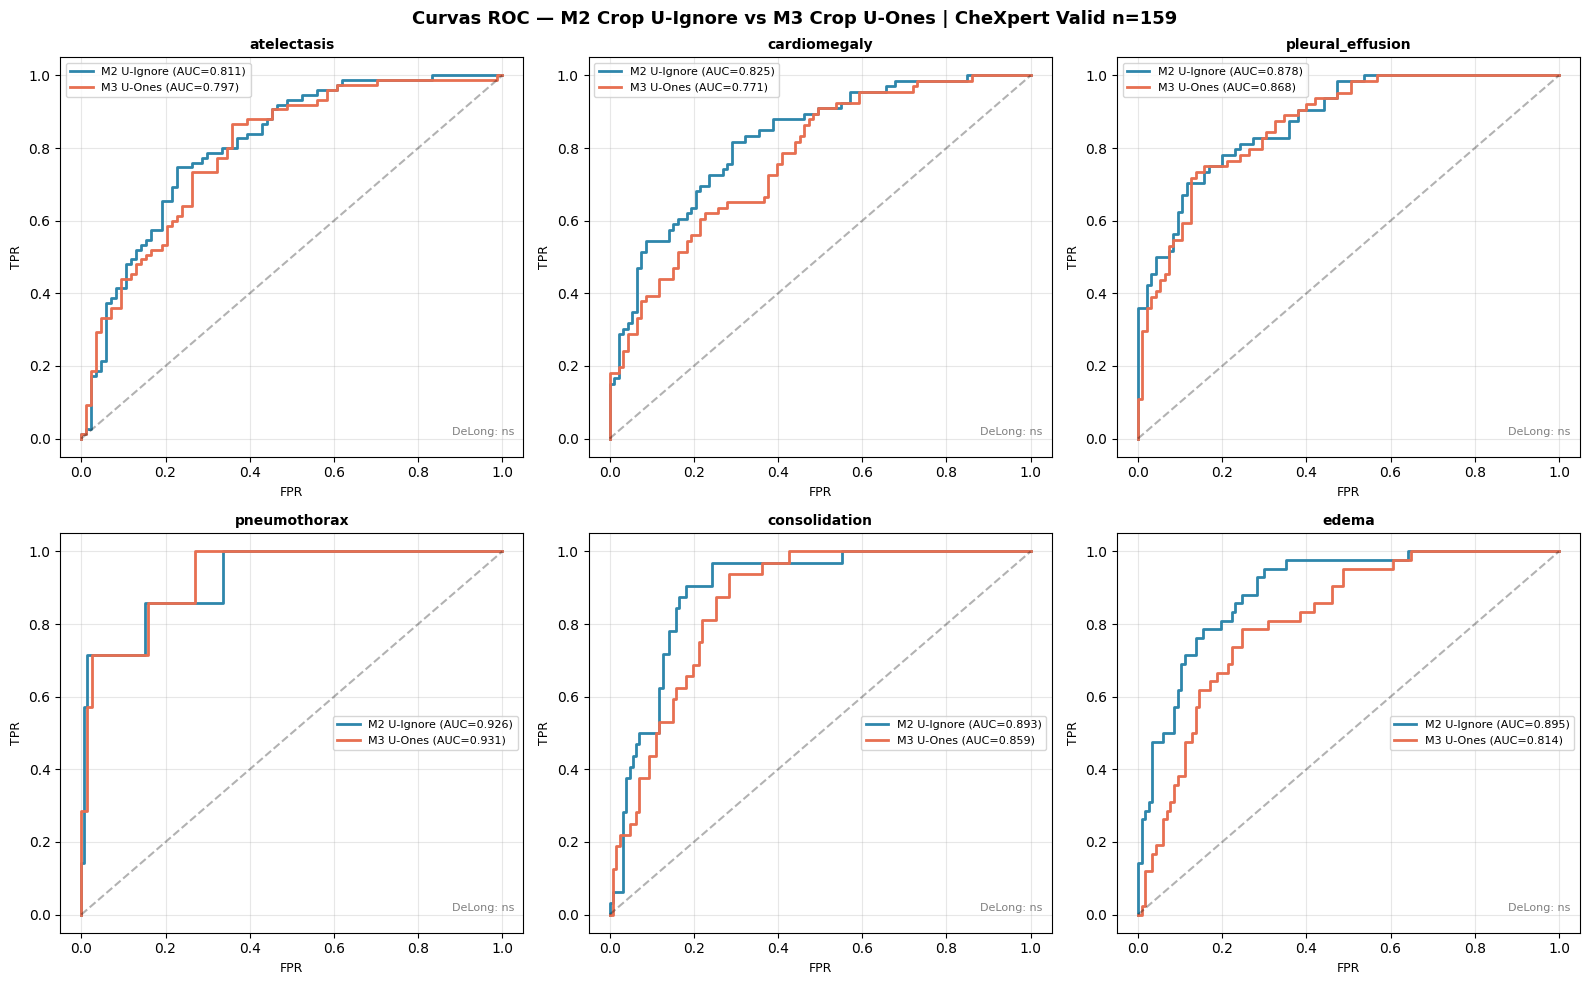

ROC curves salvas.


In [10]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curvas ROC — M2 Crop U-Ignore vs M3 Crop U-Ones | CheXpert Valid n=159',
             fontsize=13, fontweight='bold')
axes = axes.flatten()
colors = {'M2 U-Ignore':'#2E86AB', 'M3 U-Ones':'#E76F51'}

for i, lbl in enumerate(LABELS):
    ax = axes[i]
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2: continue
    for name, yp, color in [('M2 U-Ignore',y_pred_m2[:,i],'#2E86AB'),
                              ('M3 U-Ones',  y_pred_m3[:,i],'#E76F51')]:
        fpr, tpr, _ = roc_curve(yt, yp)
        auc = roc_auc_score(yt, yp)
        ax.plot(fpr, tpr, color=color, lw=2, label=f'{name} (AUC={auc:.3f})')
    ax.plot([0,1],[0,1],'k--',alpha=0.3)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_xlabel('FPR', fontsize=9); ax.set_ylabel('TPR', fontsize=9)
    ax.legend(fontsize=8); ax.grid(alpha=0.3)
    if lbl in delong_results:
        sig = delong_results[lbl]['sig']
        color_sig = 'darkgreen' if sig != 'ns' else 'gray'
        ax.text(0.98, 0.05, f'DeLong: {sig}', ha='right', va='bottom',
                fontsize=8, transform=ax.transAxes, color=color_sig)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/roc_m2_vs_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print('ROC curves salvas.')

## SEÇÃO 6 — Curvas Precision-Recall

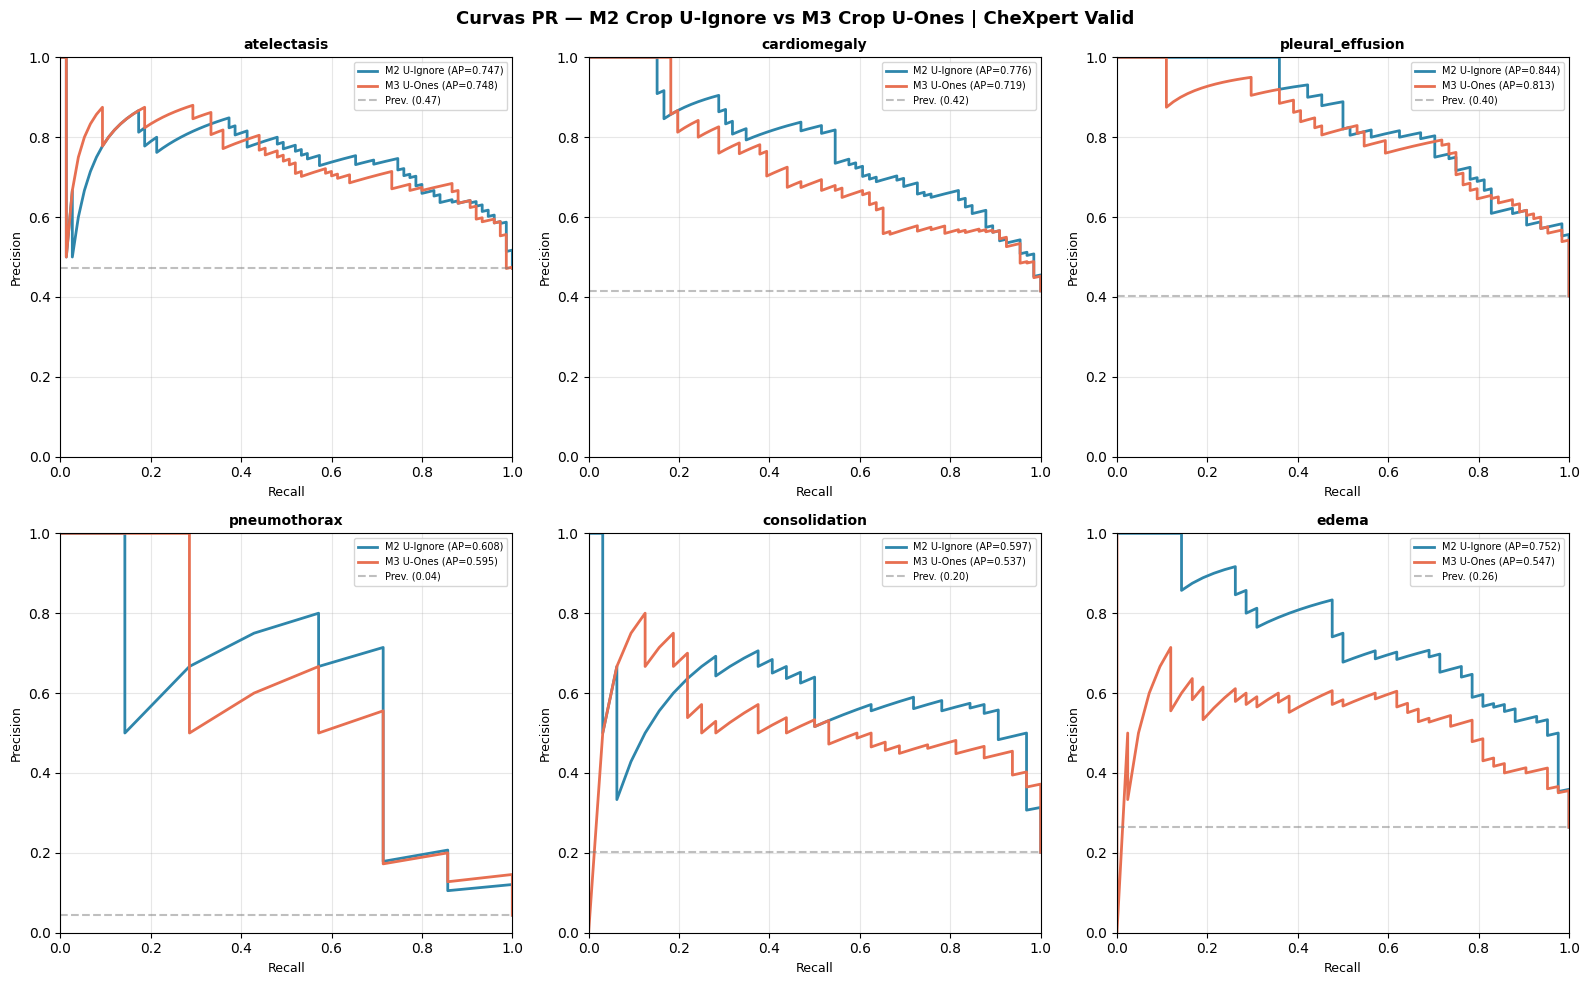

PR curves salvas.


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Curvas PR — M2 Crop U-Ignore vs M3 Crop U-Ones | CheXpert Valid',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, lbl in enumerate(LABELS):
    ax = axes[i]
    yt = y_true[:, i]
    if len(np.unique(yt)) < 2: continue
    prevalence = yt.mean()
    for name, yp, color in [('M2 U-Ignore',y_pred_m2[:,i],'#2E86AB'),
                              ('M3 U-Ones',  y_pred_m3[:,i],'#E76F51')]:
        prec, rec, _ = precision_recall_curve(yt, yp)
        ap = average_precision_score(yt, yp)
        ax.plot(rec, prec, color=color, lw=2, label=f'{name} (AP={ap:.3f})')
    ax.axhline(y=prevalence, color='gray', linestyle='--', alpha=0.5,
               label=f'Prev. ({prevalence:.2f})')
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_xlabel('Recall', fontsize=9); ax.set_ylabel('Precision', fontsize=9)
    ax.legend(fontsize=7); ax.grid(alpha=0.3)
    ax.set_xlim([0,1]); ax.set_ylim([0,1])

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/pr_m2_vs_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print('PR curves salvas.')

## SEÇÃO 7 — Comparativo Visual de Métricas

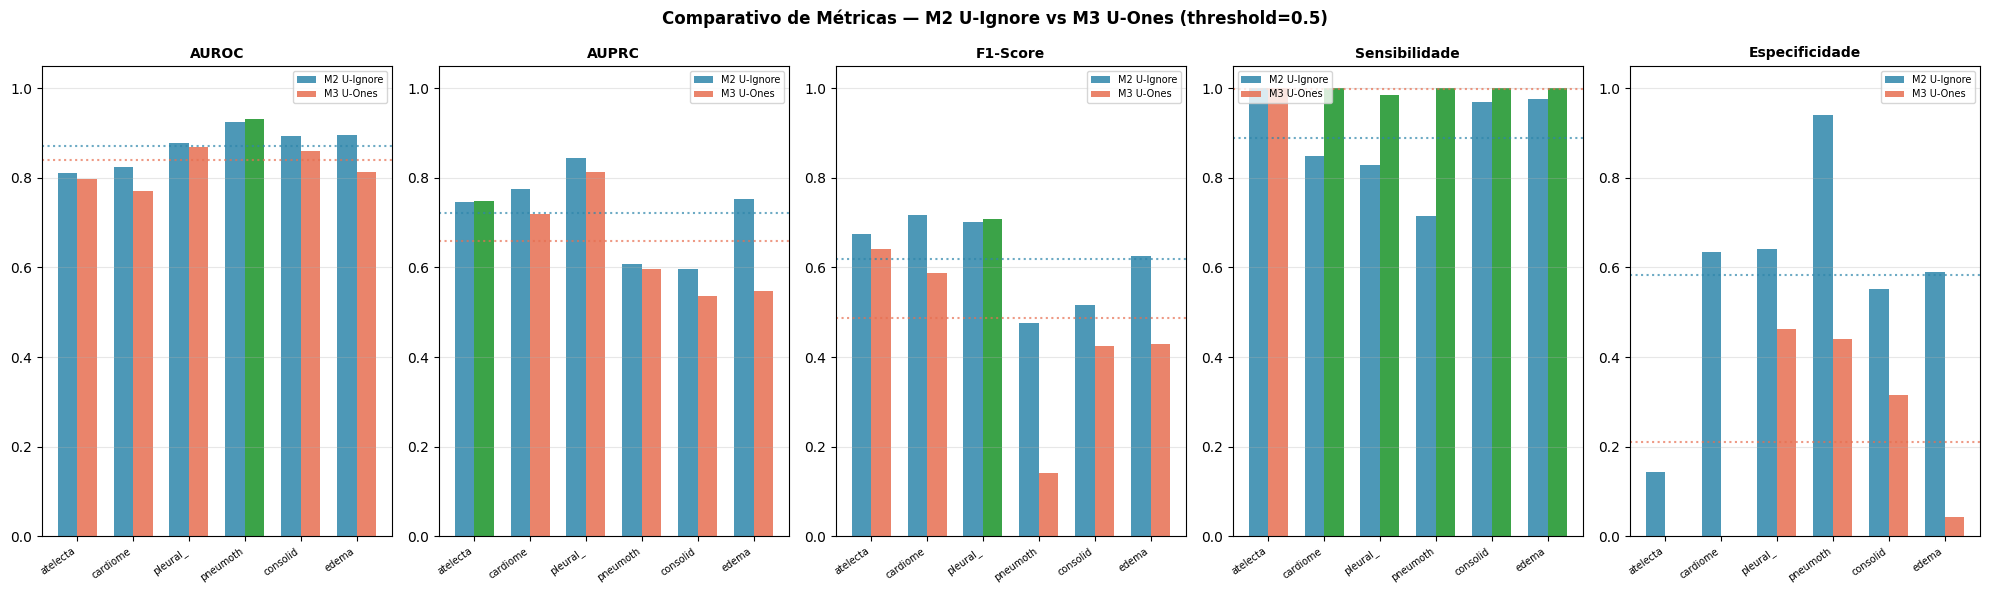

Verde = label onde M3 vence | Linhas pontilhadas = macro de cada modelo


In [12]:
metrics_list  = ['auroc','auprc','f1','sensitivity','specificity']
metric_labels = ['AUROC','AUPRC','F1-Score','Sensibilidade','Especificidade']

fig, axes = plt.subplots(1, len(metrics_list), figsize=(20, 6))
fig.suptitle('Comparativo de Métricas — M2 U-Ignore vs M3 U-Ones (threshold=0.5)',
             fontsize=12, fontweight='bold')

x = np.arange(len(LABELS))
width = 0.35

for ax, metric, mlbl in zip(axes, metrics_list, metric_labels):
    vals_m2 = [metrics_m2[lbl][metric] or 0 for lbl in LABELS]
    vals_m3 = [metrics_m3[lbl][metric] or 0 for lbl in LABELS]

    ax.bar(x - width/2, vals_m2, width, label='M2 U-Ignore', color='#2E86AB', alpha=0.85)
    ax.bar(x + width/2, vals_m3, width, label='M3 U-Ones',   color='#E76F51', alpha=0.85)

    # Destaca onde M3 vence
    for j, (v2, v3) in enumerate(zip(vals_m2, vals_m3)):
        if v3 > v2:
            ax.bar(j + width/2, v3, width, color='#28A745', alpha=0.9)

    ax.set_title(mlbl, fontweight='bold', fontsize=10)
    ax.set_xticks(x)
    ax.set_xticklabels([l[:8] for l in LABELS], rotation=35, ha='right', fontsize=7)
    ax.set_ylim(0, 1.05)
    ax.legend(fontsize=7); ax.grid(axis='y', alpha=0.3)
    # Macro lines
    ax.axhline(y=metrics_m2['MACRO'][metric] or 0, color='#2E86AB', linestyle=':', alpha=0.7)
    ax.axhline(y=metrics_m3['MACRO'][metric] or 0, color='#E76F51', linestyle=':', alpha=0.7)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/metrics_m2_vs_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Verde = label onde M3 vence | Linhas pontilhadas = macro de cada modelo')

## SEÇÃO 8 — Distribuição de Scores por Label

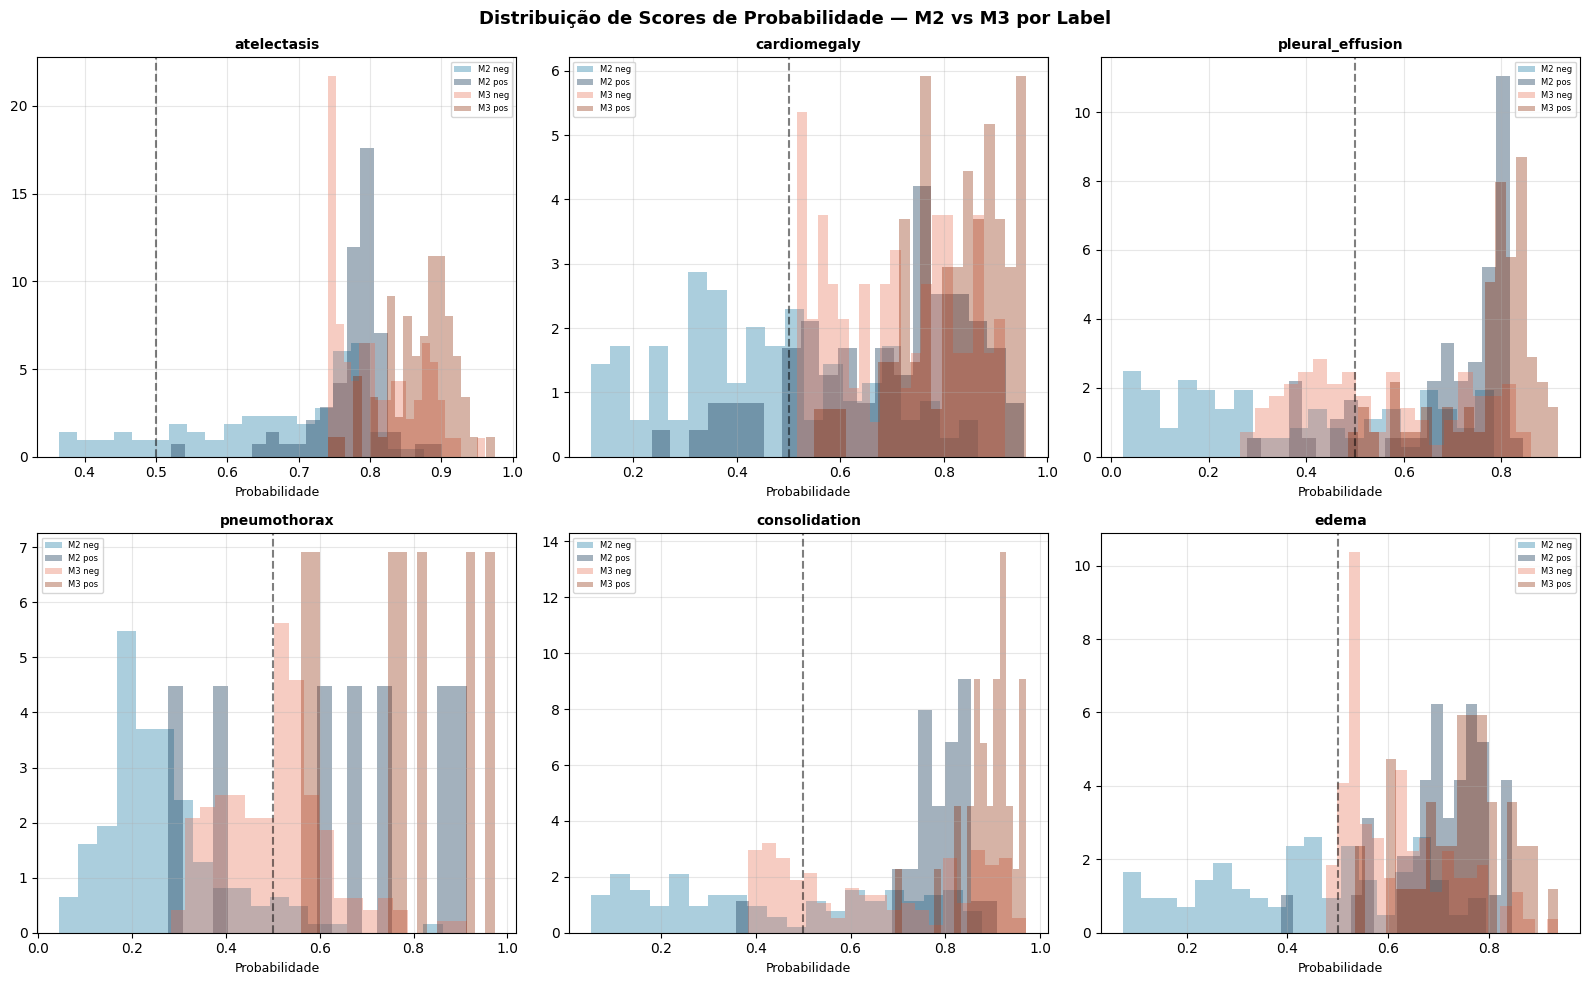

Distribuição de scores salva.


In [13]:
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Distribuição de Scores de Probabilidade — M2 vs M3 por Label',
             fontsize=13, fontweight='bold')
axes = axes.flatten()

for i, lbl in enumerate(LABELS):
    ax = axes[i]
    yt = y_true[:, i]
    pos_mask = yt == 1
    neg_mask = yt == 0

    # M2
    ax.hist(y_pred_m2[neg_mask, i], bins=20, alpha=0.4, color='#2E86AB',
            density=True, label='M2 neg')
    ax.hist(y_pred_m2[pos_mask, i], bins=20, alpha=0.4, color='#1A3D5C',
            density=True, label='M2 pos')
    # M3
    ax.hist(y_pred_m3[neg_mask, i], bins=20, alpha=0.35, color='#E76F51',
            density=True, label='M3 neg')
    ax.hist(y_pred_m3[pos_mask, i], bins=20, alpha=0.35, color='#8B2500',
            density=True, label='M3 pos')

    ax.axvline(x=0.5, color='black', linestyle='--', alpha=0.5)
    ax.set_title(lbl, fontweight='bold', fontsize=10)
    ax.set_xlabel('Probabilidade', fontsize=9)
    ax.legend(fontsize=6); ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(f'{OUT_DIR}/score_dist_m2_vs_m3.png', dpi=150, bbox_inches='tight')
plt.show()
print('Distribuição de scores salva.')

## SEÇÃO 8.5 — Grad-CAM: Funções de Visualização

In [17]:
def get_gradcam(model, img_tensor, class_idx, last_conv_layer_name=None):
    """Gera heatmap Grad-CAM — busca camada conv pelo nome antes do fallback."""
    if last_conv_layer_name is None:
        candidates = ['block14_sepconv2_act', 'block14_sepconv2_bn',
                      'block14_sepconv1_act', 'block13_sepconv2_act']
        for name in candidates:
            try:
                model.get_layer(name)
                last_conv_layer_name = name
                break
            except ValueError:
                continue
        if last_conv_layer_name is None:
            for layer in reversed(model.layers):
                if (hasattr(layer, 'output_shape') and
                    isinstance(layer.output_shape, tuple) and
                    len(layer.output_shape) == 4 and
                    'dense'   not in layer.name.lower() and
                    'dropout' not in layer.name.lower()):
                    last_conv_layer_name = layer.name
                    break
    if last_conv_layer_name is None:
        raise ValueError('Nenhuma camada conv encontrada no modelo')

    grad_model = tf.keras.Model(
        inputs=model.input,
        outputs=[model.get_layer(last_conv_layer_name).output, model.output]
    )
    with tf.GradientTape() as tape:
        img_batch = tf.expand_dims(img_tensor, 0)
        conv_outputs, predictions = grad_model(img_batch)
        loss = predictions[:, class_idx]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    conv_outputs = conv_outputs[0]
    heatmap      = conv_outputs @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0) / (tf.math.reduce_max(heatmap) + 1e-7)
    return heatmap.numpy(), float(predictions[0, class_idx])


def overlay_gradcam(img_path, heatmap, alpha=0.4):
    """Sobrepõe Grad-CAM em colormap jet sobre a imagem original."""
    img     = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    img_rgb = np.stack([np.array(img)] * 3, axis=-1)

    heatmap_resized = np.array(
        PILImage.fromarray((heatmap * 255).astype(np.uint8)).resize((IMG_SIZE, IMG_SIZE))
    )
    heatmap_color = plt.cm.jet(heatmap_resized / 255.0)[:, :, :3] * 255
    overlay = (img_rgb * (1 - alpha) + heatmap_color * alpha).astype(np.uint8)
    return overlay, img_rgb


print('Funções Grad-CAM definidas.')
print('Camada alvo: block14_sepconv2_act (Xception)')

Funções Grad-CAM definidas.
Camada alvo: block14_sepconv2_act (Xception)


## SEÇÃO 9 — Exemplos de Inferência Individual

=== Pneumothorax (M3 vence +0.0066) ===


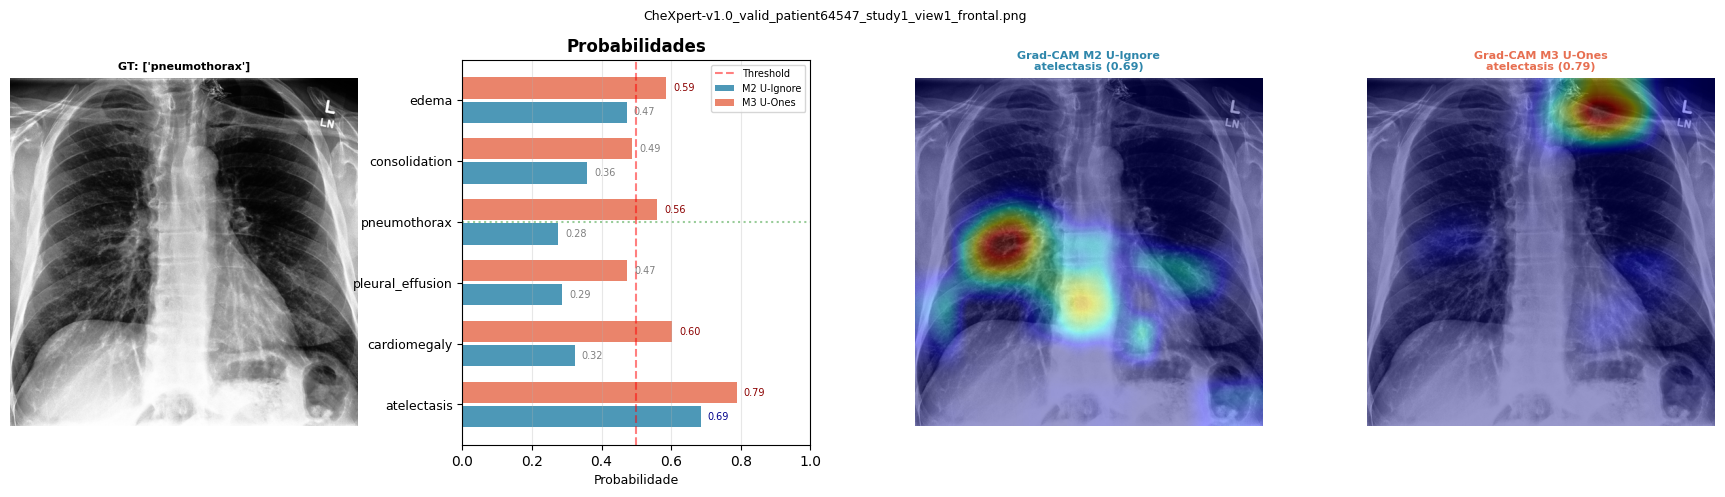

  Label                       M2      M3       Δ   GT
  ----------------------------------------------------
  atelectasis              0.685   0.788  +0.103    0
  cardiomegaly             0.323   0.604  +0.281    0
  pleural_effusion         0.287   0.474  +0.187    0
  pneumothorax             0.276   0.559  +0.283   +1
  consolidation            0.358   0.487  +0.129    0
  edema                    0.472   0.586  +0.114    0

=== Edema (M3 perde -0.0812) ===


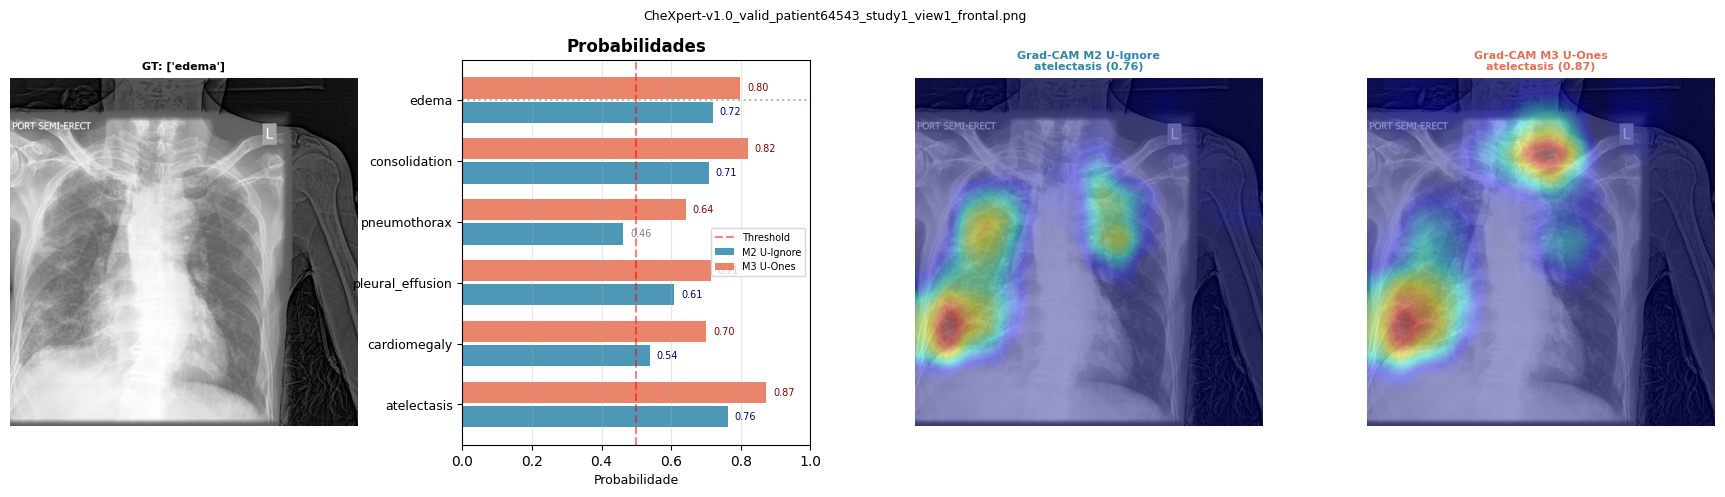

  Label                       M2      M3       Δ   GT
  ----------------------------------------------------
  atelectasis              0.762   0.874  +0.112    0
  cardiomegaly             0.539   0.701  +0.162    0
  pleural_effusion         0.609   0.714  +0.105    0
  pneumothorax             0.463   0.642  +0.179    0
  consolidation            0.708   0.820  +0.113    0
  edema                    0.719   0.798  +0.079   +1

=== Multiplas patologias ===


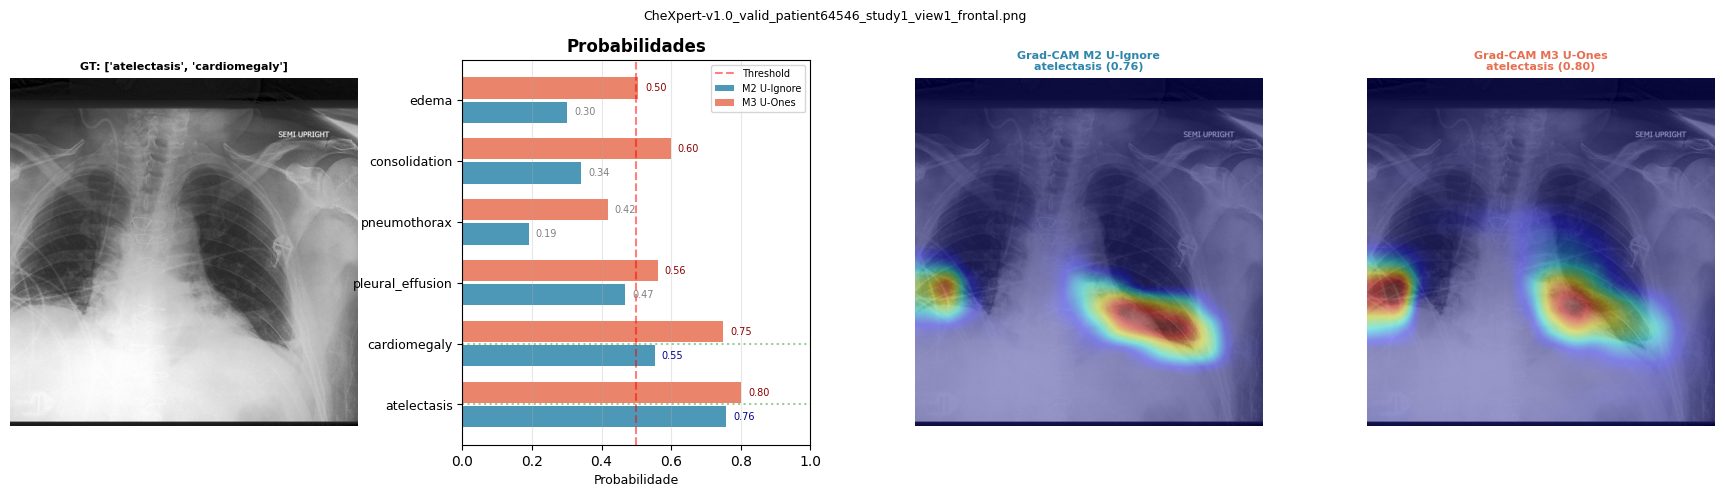

  Label                       M2      M3       Δ   GT
  ----------------------------------------------------
  atelectasis              0.758   0.802  +0.044   +1
  cardiomegaly             0.553   0.749  +0.197   +1
  pleural_effusion         0.467   0.562  +0.094    0
  pneumothorax             0.190   0.417  +0.227    0
  consolidation            0.342   0.598  +0.257    0
  edema                    0.301   0.505  +0.204    0


In [18]:
def predict_single_m2_m3(img_path, labels, y_true_row=None, show_gradcam=True):
    """
    Compara predições M2 vs M3 para uma imagem.
    Layout: Imagem original | Probabilidades | Grad-CAM M2 | Grad-CAM M3
    """
    img_tensor = preprocess_image(img_path)
    pred_m2 = model_m2(tf.expand_dims(img_tensor, 0), training=False).numpy()[0]
    pred_m3 = model_m3(tf.expand_dims(img_tensor, 0), training=False).numpy()[0]

    n_labels = len(labels)
    ncols = 4 if show_gradcam else 2
    fig   = plt.figure(figsize=(22 if show_gradcam else 14, 5))
    gs    = gridspec.GridSpec(1, ncols, figure=fig, wspace=0.3)

    # ── Imagem original ───────────────────────────────────────────────────────
    ax_img = fig.add_subplot(gs[0, 0])
    raw = PILImage.open(img_path).convert('L').resize((IMG_SIZE, IMG_SIZE))
    ax_img.imshow(np.array(raw), cmap='gray')
    if y_true_row is not None:
        pos_labels = [labels[j] for j in range(n_labels) if y_true_row[j] == 1]
        ax_img.set_title(f'GT: {pos_labels}', fontweight='bold', fontsize=8)
    else:
        ax_img.set_title('Imagem Original', fontweight='bold')
    ax_img.axis('off')

    # ── Probabilidades M2 vs M3 ───────────────────────────────────────────────
    ax_bar = fig.add_subplot(gs[0, 1])
    y_pos  = np.arange(n_labels)
    ax_bar.barh(y_pos - 0.2, pred_m2, 0.35, label='M2 U-Ignore', color='#2E86AB', alpha=0.85)
    ax_bar.barh(y_pos + 0.2, pred_m3, 0.35, label='M3 U-Ones',   color='#E76F51', alpha=0.85)
    ax_bar.axvline(x=0.5, color='red', linestyle='--', alpha=0.5, label='Threshold')
    if y_true_row is not None:
        for j, gt in enumerate(y_true_row):
            if gt == 1:
                ax_bar.axhline(y=j, color='green', linestyle=':', alpha=0.4, linewidth=1.5)
    ax_bar.set_yticks(y_pos)
    ax_bar.set_yticklabels(labels, fontsize=9)
    ax_bar.set_xlabel('Probabilidade', fontsize=9)
    ax_bar.set_xlim(0, 1)
    ax_bar.set_title('Probabilidades', fontweight='bold')
    ax_bar.legend(fontsize=7); ax_bar.grid(axis='x', alpha=0.3)
    for j, (p2, p3) in enumerate(zip(pred_m2, pred_m3)):
        ax_bar.text(min(p2+0.02, 0.96), j-0.2, f'{p2:.2f}', va='center',
                    fontsize=7, color='darkblue' if p2>0.5 else 'gray')
        ax_bar.text(min(p3+0.02, 0.96), j+0.2, f'{p3:.2f}', va='center',
                    fontsize=7, color='darkred' if p3>0.5 else 'gray')

    # ── Grad-CAM M2 e M3 — label mais provável pelo M2 ───────────────────────
    if show_gradcam:
        top_idx = int(np.argmax(pred_m2))  # label de referência: top M2

        for col, (model_name, model, pred, color) in enumerate([
            ('M2 U-Ignore', model_m2, pred_m2, '#2E86AB'),
            ('M3 U-Ones',   model_m3, pred_m3, '#E76F51'),
        ]):
            ax_cam = fig.add_subplot(gs[0, 2 + col])
            try:
                heatmap, conf = get_gradcam(model, img_tensor, top_idx)
                overlay, _    = overlay_gradcam(img_path, heatmap)
                ax_cam.imshow(overlay)
                ax_cam.set_title(
                    f'Grad-CAM {model_name}\n{labels[top_idx]} ({conf:.2f})',
                    fontweight='bold', fontsize=8, color=color
                )
            except Exception as e:
                ax_cam.text(0.5, 0.5,
                    f'Grad-CAM\nindisponivel\n{str(e)[:25]}',
                    ha='center', va='center', fontsize=7)
                ax_cam.set_title(f'Grad-CAM {model_name}', fontsize=8)
            ax_cam.axis('off')

    fig.suptitle(img_path.split('/')[-1], fontsize=9)
    plt.tight_layout(); plt.show()

    print(f'  {"Label":<22} {"M2":>7} {"M3":>7} {"Δ":>7} {"GT":>4}')
    print('  ' + '-'*52)
    for j, lbl in enumerate(labels):
        gt_str = '+1' if (y_true_row is not None and y_true_row[j] == 1) else ' 0'
        delta  = pred_m3[j] - pred_m2[j]
        print(f'  {lbl:<22} {pred_m2[j]:>7.3f} {pred_m3[j]:>7.3f} {delta:>+7.3f} {gt_str:>4}')
    return pred_m2, pred_m3


# ── Exemplos por patologia ────────────────────────────────────────────────────
df_valid['n_pos'] = df_valid[LABELS].sum(axis=1)

# Pneumothorax — único label onde M3 vence
pneumo_idx = df_valid[df_valid['pneumothorax'] == 1].index.tolist()
if pneumo_idx:
    print('=== Pneumothorax (M3 vence +0.0066) ===')
    predict_single_m2_m3(df_valid.loc[pneumo_idx[0], 'img_path'], LABELS,
                          y_true[pneumo_idx[0]])

# Edema — maior queda do M3 (-0.0812)
edema_idx = df_valid[df_valid['edema'] == 1].index.tolist()
if edema_idx:
    print('\n=== Edema (M3 perde -0.0812) ===')
    predict_single_m2_m3(df_valid.loc[edema_idx[0], 'img_path'], LABELS,
                          y_true[edema_idx[0]])

# Multi-label
multi_idx = df_valid[df_valid['n_pos'] >= 2].index.tolist()
if len(multi_idx) > 1:
    print('\n=== Multiplas patologias ===')
    predict_single_m2_m3(df_valid.loc[multi_idx[1], 'img_path'], LABELS,
                          y_true[multi_idx[1]])

## SEÇÃO 10 — Resumo Final e Decisão M4

In [19]:
print('='*70)
print('RESUMO — M2 Crop U-Ignore vs M3 Crop U-Ones')
print('Variável isolada: política de labels incertos (-1)')
print('='*70)

print(f'\n{"Label":<22} {"M2 AUROC":>9} {"M3 AUROC":>9} {"Δ":>8} {"DeLong":>7} {"Vencedor":>10}')
print('-'*68)
m2_wins = m3_wins = 0
for lbl in LABELS:
    a2 = metrics_m2[lbl]['auroc']
    a3 = metrics_m3[lbl]['auroc']
    if a2 is None: continue
    delta = a3 - a2
    sig   = delong_results.get(lbl,{}).get('sig','—')
    winner = 'M2' if delta < 0 else 'M3'
    if delta < 0: m2_wins += 1
    else: m3_wins += 1
    print(f'{lbl:<22} {a2:>9.4f} {a3:>9.4f} {delta:>+8.4f} {sig:>7}  {winner}')
print('-'*68)
a2m = metrics_m2['MACRO']['auroc']
a3m = metrics_m3['MACRO']['auroc']
print(f'{"MACRO":<22} {a2m:>9.4f} {a3m:>9.4f} {a3m-a2m:>+8.4f}')
print()
print(f'  M2 U-Ignore vence : {m2_wins}/6 labels')
print(f'  M3 U-Ones vence   : {m3_wins}/6 labels')
print()
print(f'  CONCLUSÃO: U-Ignore (M2) supera U-Ones irrestrito (M3)')
print(f'  Único ganho M3: Pneumothorax (+{metrics_m3["pneumothorax"]["auroc"]-metrics_m2["pneumothorax"]["auroc"]:+.4f})')
print(f'  Maior perda M3: Edema ({metrics_m3["edema"]["auroc"]-metrics_m2["edema"]["auroc"]:+.4f})')
print()
print('  DECISÃO PARA M4:')
print('  → Política diferenciada por label (U-Ones seletivo)')
print('  → Ponto de partida: m2_crop_final.keras')
print('  → Labels para U-Ones: pneumothorax, atelectasis, pleural_effusion')
print('  → Labels para U-Ignore: edema, cardiomegaly, consolidation')
print('='*70)

RESUMO — M2 Crop U-Ignore vs M3 Crop U-Ones
Variável isolada: política de labels incertos (-1)

Label                   M2 AUROC  M3 AUROC        Δ  DeLong   Vencedor
--------------------------------------------------------------------
atelectasis               0.8106    0.7970  -0.0137      ns  M2
cardiomegaly              0.8252    0.7714  -0.0538      ns  M2
pleural_effusion          0.8776    0.8684  -0.0092      ns  M2
pneumothorax              0.9258    0.9314  +0.0056      ns  M3
consolidation             0.8932    0.8595  -0.0337      ns  M2
edema                     0.8946    0.8136  -0.0810      ns  M2
--------------------------------------------------------------------
MACRO                     0.8712    0.8402  -0.0309

  M2 U-Ignore vence : 5/6 labels
  M3 U-Ones vence   : 1/6 labels

  CONCLUSÃO: U-Ignore (M2) supera U-Ones irrestrito (M3)
  Único ganho M3: Pneumothorax (++0.0056)
  Maior perda M3: Edema (-0.0810)

  DECISÃO PARA M4:
  → Política diferenciada por label (U

## SEÇÃO 11 — Relatório

In [20]:
!pip install -q anthropic
import anthropic

API_KEY = '<API_KEY>'
client  = anthropic.Anthropic(api_key=API_KEY)

if 'metrics_m2' not in dir() or 'metrics_m3' not in dir():
    with open(f'{OUT_DIR}/metrics_m2_vs_m3.json') as f:
        comp = json.load(f)
    metrics_m2 = comp['m2_crop_uignore']
    metrics_m3 = comp['m3_crop_uones']

# Carrega M1 para trajetória completa
try:
    with open(f'{BASE}/datasets_pi_2026/modelos/M1_NIH/m1_results.json') as f:
        m1_res = json.load(f)
    m1_macro = m1_res['macro_auroc']; m1_pl = m1_res['per_label_auroc']
except Exception:
    m1_macro = None; m1_pl = {}

# ── Monta variáveis auxiliares ─────────────────────────────────────────────
label_lines = []
for lbl in LABELS:
    m1v  = m1_pl.get(lbl, 0)
    m2v  = metrics_m2.get(lbl,{}).get('auroc', 0)
    m3v  = metrics_m3.get(lbl,{}).get('auroc', 0)
    f1m2 = metrics_m2.get(lbl,{}).get('f1', 0)
    f1m3 = metrics_m3.get(lbl,{}).get('f1', 0)
    sm2  = metrics_m2.get(lbl,{}).get('sensitivity', 0)
    sm3  = metrics_m3.get(lbl,{}).get('sensitivity', 0)
    spm2 = metrics_m2.get(lbl,{}).get('specificity', 0)
    spm3 = metrics_m3.get(lbl,{}).get('specificity', 0)
    sig  = delong_results.get(lbl,{}).get('sig','N/A')
    p    = delong_results.get(lbl,{}).get('p', None)
    p_str = f'{p:.4f}' if p else 'N/A'
    label_lines.append(
        f'  {lbl:<22}: M1={m1v:.4f} | M2={m2v:.4f} | M3={m3v:.4f} | '
        f'ΔM2→M3={m3v-m2v:+.4f} | F1 M2={f1m2:.4f} | F1 M3={f1m3:.4f} | '
        f'Sens M2={sm2:.4f}/M3={sm3:.4f} | Spec M2={spm2:.4f}/M3={spm3:.4f} | '
        f'DeLong={sig} p={p_str}'
    )

label_table  = '\n'.join(label_lines)
separador    = '─' * 70
m1_str       = f'{m1_macro:.4f}' if m1_macro else 'N/A'
mac2         = metrics_m2.get('MACRO',{})
mac3         = metrics_m3.get('MACRO',{})
delta_macro  = f'{mac3.get("auroc",0)-mac2.get("auroc",0):+.4f}'
status_m3    = 'Atingido' if mac3.get('auroc',0) >= 0.85 else 'Abaixo do target'
sig_labels   = [l for l,d in delong_results.items() if d.get('sig','ns') not in ['ns','N/A']]

context = f"""
EXPERIMENTO: Comparativo M2 Crop U-Ignore vs M3 Crop U-Ones
VARIÁVEL ISOLADA: Política de tratamento dos labels incertos (-1 no CheXpert)
  M2: U-Ignore — labels -1 descartados da loss (sem máscara para exemplos incertos)
  M3: U-Ones   — labels -1 convertidos para +1 + Label Smoothing ε=0.05
TUDO O MAIS É IDÊNTICO: Xception 512×512, Center Crop, Focal Loss γ=2.0, mesmo valid set

CONFIGURAÇÃO M2 (referência):
  Política      : U-Ignore | positivos efetivos = apenas confirmados
  Macro-AUROC   : {mac2.get('auroc',0):.4f}

CONFIGURAÇÃO M3 (experimental):
  Política      : U-Ones | positivos efetivos = confirmados + incertos convertidos
  Label Smoothing: ε=0.05 (targets 1→0.95, 0→0.05)
  Macro-AUROC   : {mac3.get('auroc',0):.4f}
  Status target : {status_m3}

VOLUME DE INCERTOS CONVERTIDOS POR LABEL (M3):
  atelectasis    : +33.739 incertos → +1  (19.865→53.604 positivos, +169.8%)
  consolidation  : +27.742 incertos → +1  (12.983→40.725 positivos, +213.7%)
  edema          : +12.984 incertos → +1  (27.102→40.086 positivos, +47.9%)
  pleural_effusion: +11.628 incertos → +1 (37.752→49.380 positivos, +30.8%)
  cardiomegaly   : +8.087  incertos → +1  (17.504→25.591 positivos, +46.2%)
  pneumothorax   : +3.145  incertos → +1  (15.410→18.555 positivos, +20.4%)

RESULTADOS COMPLETOS — M1 | M2 U-Ignore | M3 U-Ones:
{label_table}
  {separador}
  M1  Macro-AUROC : {m1_str}
  M2  Macro-AUROC : {mac2.get('auroc',0):.4f} | AUPRC={mac2.get('auprc',0):.4f} | F1={mac2.get('f1',0):.4f} | Sens={mac2.get('sensitivity',0):.4f} | Spec={mac2.get('specificity',0):.4f}
  M3  Macro-AUROC : {mac3.get('auroc',0):.4f} | AUPRC={mac3.get('auprc',0):.4f} | F1={mac3.get('f1',0):.4f} | Sens={mac3.get('sensitivity',0):.4f} | Spec={mac3.get('specificity',0):.4f}
  ΔM2→M3          : AUROC={delta_macro} | AUPRC={mac3.get('auprc',0)-mac2.get('auprc',0):+.4f} | F1={mac3.get('f1',0)-mac2.get('f1',0):+.4f}

TESTE DELONG (n=159):
  Labels significativos (p<0.05): {sig_labels if sig_labels else 'nenhum — todos ns'}
  Maior z-score: {max(delong_results.items(), key=lambda x: abs(x[1]['z']))[0]} (z={max(delong_results.items(), key=lambda x: abs(x[1]['z']))[1]['z']:.3f})
"""

prompt = f"""Você é um pesquisador sênior em visão computacional médica.

Abaixo estão os resultados do comparativo M2 U-Ignore vs M3 U-Ones — parte central do ablation study de classificação multi-label de CXR com Xception 512×512 no CheXpert.

{context}

Produza um relatório técnico estruturado cobrindo:

1. **Resumo executivo**: U-Ones foi benéfico ou prejudicial? Qual o veredicto para o ablation?
2. **Análise por label**: relacione o delta de AUROC com o volume e qualidade esperada dos incertos convertidos para cada patologia. Por que pneumothorax ganhou e edema perdeu?
3. **Além do AUROC**: F1, sensibilidade e especificidade confirmam o resultado? Há trade-offs operacionais relevantes?
4. **AUPRC**: o resultado AUPRC confirma ou diverge do AUROC?
5. **DeLong**: interprete os p-values no contexto de n=159. A consistência direcional (M2 superior em 5/6) é evidência suficiente?
6. **Mecanismo do Label Smoothing**: ε=0.05 foi adequado para compensar o ruído do U-Ones? O que deveria mudar?
7. **Implicações para M4**: política diferenciada por label — quais labels devem receber U-Ones e quais U-Ignore? Justifique por patologia.
8. **Ponto de partida do M4**: M2 ou M3? Justifique tecnicamente.
9. **Limitações**: o que n=159 não pode garantir?

Seja direto, técnico e cite os números. Responda em português brasileiro."""

print('Enviando para Claude API...')
t0 = time.time()
message = client.messages.create(
    model='claude-sonnet-4-6', max_tokens=8192,
    messages=[{'role':'user','content':prompt}]
)
relatorio = message.content[0].text
elapsed   = time.time() - t0
print(f'Resposta em {elapsed:.1f}s | {message.usage.input_tokens} in | {message.usage.output_tokens} out')

print('\n' + '='*65)
print('RELATÓRIO COMPARATIVO M2 vs M3 — Claude Sonnet')
print('='*65)
print(relatorio)

report_path = f'{OUT_DIR}/relatorio_m2_vs_m3_claude.txt'
with open(report_path, 'w', encoding='utf-8') as f:
    f.write(context + '\n\n' + '='*65 + '\nRELATÓRIO CLAUDE\n' + '='*65 + '\n\n' + relatorio)
print(f'\nRelatório salvo: {report_path}')

Enviando para Claude API...
Resposta em 133.2s | 1967 in | 6830 out

RELATÓRIO COMPARATIVO M2 vs M3 — Claude Sonnet
# Relatório Técnico: Ablation Study M2 U-Ignore vs M3 U-Ones
### Classificação Multi-Label CXR — Xception 512×512 — CheXpert

---

## 1. Resumo Executivo

**U-Ones foi prejudicial. Veredicto: M2 U-Ignore é superior.**

A conversão irrestrita de labels incertos (-1 → +1) com Label Smoothing ε=0.05 produziu regressão consistente e substancial em quase todas as métricas:

| Métrica | M2 U-Ignore | M3 U-Ones | Δ |
|---|---|---|---|
| Macro-AUROC | 0.8712 | 0.8402 | **−0.0309** |
| AUPRC | 0.7209 | 0.6599 | **−0.0610** |
| Macro-F1 | 0.6191 | 0.4882 | **−0.1308** |
| Especificidade | 0.5835 | 0.2103 | **−0.3732** |
| Sensibilidade | 0.8893 | 0.9974 | +0.1081 |

M3 supera M2 em apenas 1/6 labels no AUROC (pneumothorax, +0.0056) e em sensibilidade global, mas ao custo de colapso da especificidade. O modelo M3 aprendeu a predizer positivo indiscriminadamente — comportamento consi